In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd
from matplotlib.animation import FuncAnimation

## Creamos el caminante aleatorio

In [11]:

# Parametros
N = 1000 # numero de pasos
nw = 100 # Numero de caminantes
dr = 0.2  # Distancia de paso radial

dist = np.zeros([nw,N], dtype= float)
angulo = np.zeros([nw,N], dtype= float)

x = np.zeros_like(dist)
y = np.zeros_like(dist)


for i in range(N):
    for k in range(nw):
        angle = np.deg2rad(rd.randint(0,359)) # Angulo aleatorio en radianes
        dice = rd.random()
        if dice < 0.5:
            dist[k,i] = dist[k,i-1] + dr
            x[k,i] = x[k,i-1] + dr*np.cos(angle)
            y[k,i] = y[k,i-1] + dr*np.sin(angle)
        else:
            dist[k,i] = dist[k,i-1] - dr
            x[k,i] = x[k,i-1] - dr*np.cos(angle)
            y[k,i] = y[k,i-1] - dr*np.sin(angle)



## Creamos los promedios

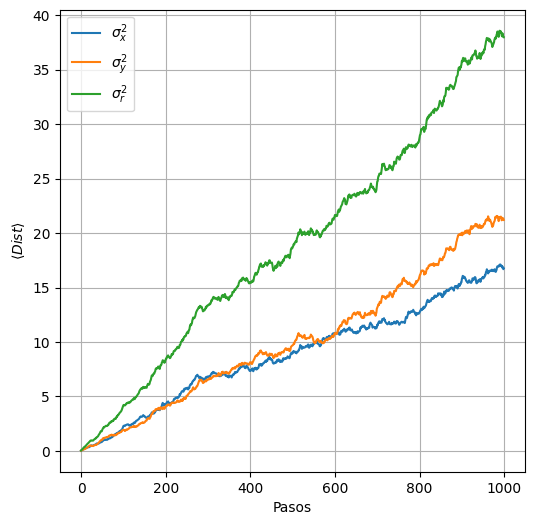

In [15]:
x2p = np.sum(x**2,0)/nw
y2p = np.sum(y**2,0)/nw

r2 = (x**2 + y**2)
r2p = np.sum(r2,0)/nw

n = np.arange(0,N)

figura, eje = plt.subplots(figsize = (6,6))
eje.plot(n, x2p, label = r'$\sigma _x^2$')
eje.plot(n, y2p, label = r'$\sigma _y^2$')
eje.plot(n, r2p, label = r'$\sigma _r^2$')

eje.set_xlabel('Pasos')
eje.set_ylabel(r'$ \langle Dist \rangle $')
eje.legend()
eje.grid()


In [13]:
# fig, ax = plt.subplots(subplot_kw={'projection':'polar'})

# colores = plt.cm.viridis(np.linspace(0,1,N))

# lineas = []
# for i in range(nw):
#     caminante = []
#     for j in range(N-1):
#         l, = ax.plot([],[], color=colores[j])
#         caminante.append(l)
#     lineas.append(caminante)



# def update(frame):

#     for w in range(nw):
#         for j in range(frame):
#             lineas[w][j].set_data(
#                 angulo[w,j:j+2],
#                 dist[w,j:j+2]
#             )

#     return sum(lineas,[])

# anim = FuncAnimation(fig, func= update, frames= N, interval = 100, blit = True)

# #plt.show()
# anim.save('Random_polar.mp4', writer= 'ffmpeg')